<a href="https://colab.research.google.com/github/rezve66/Rice-leaf-pca-analysis/blob/main/Rice_Leaf_Control_Disease_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload two images: control first or disease first.


Saving Control (2).jpg to Control (2) (2).jpg
Saving Disease (2).jpg to Disease (2) (2).jpg

Uploaded files:
0 : Control (2) (2).jpg
1 : Disease (2) (2).jpg

Enter CONTROL image number: 0
Enter DISEASE image number: 1


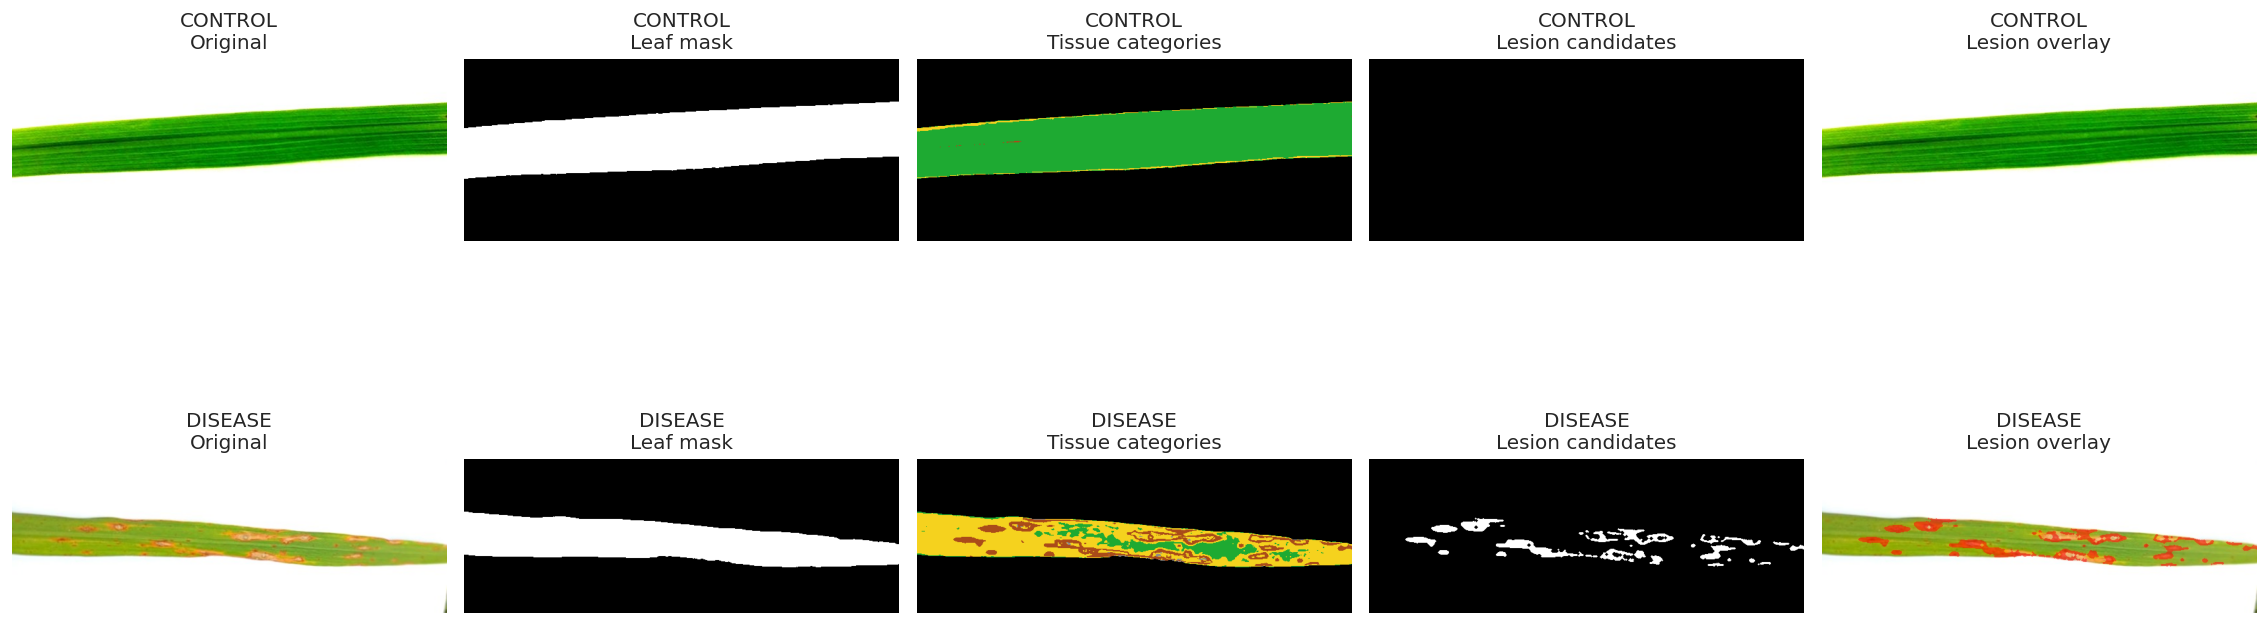

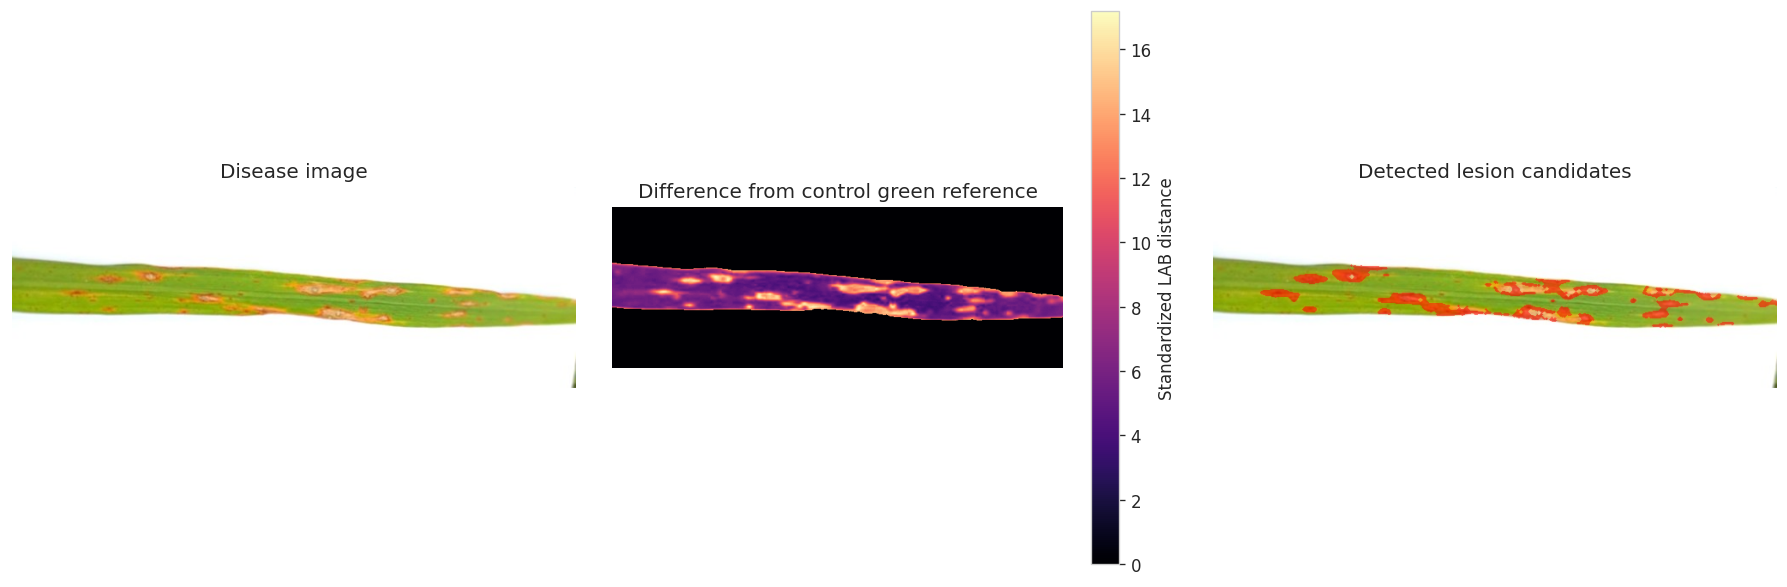

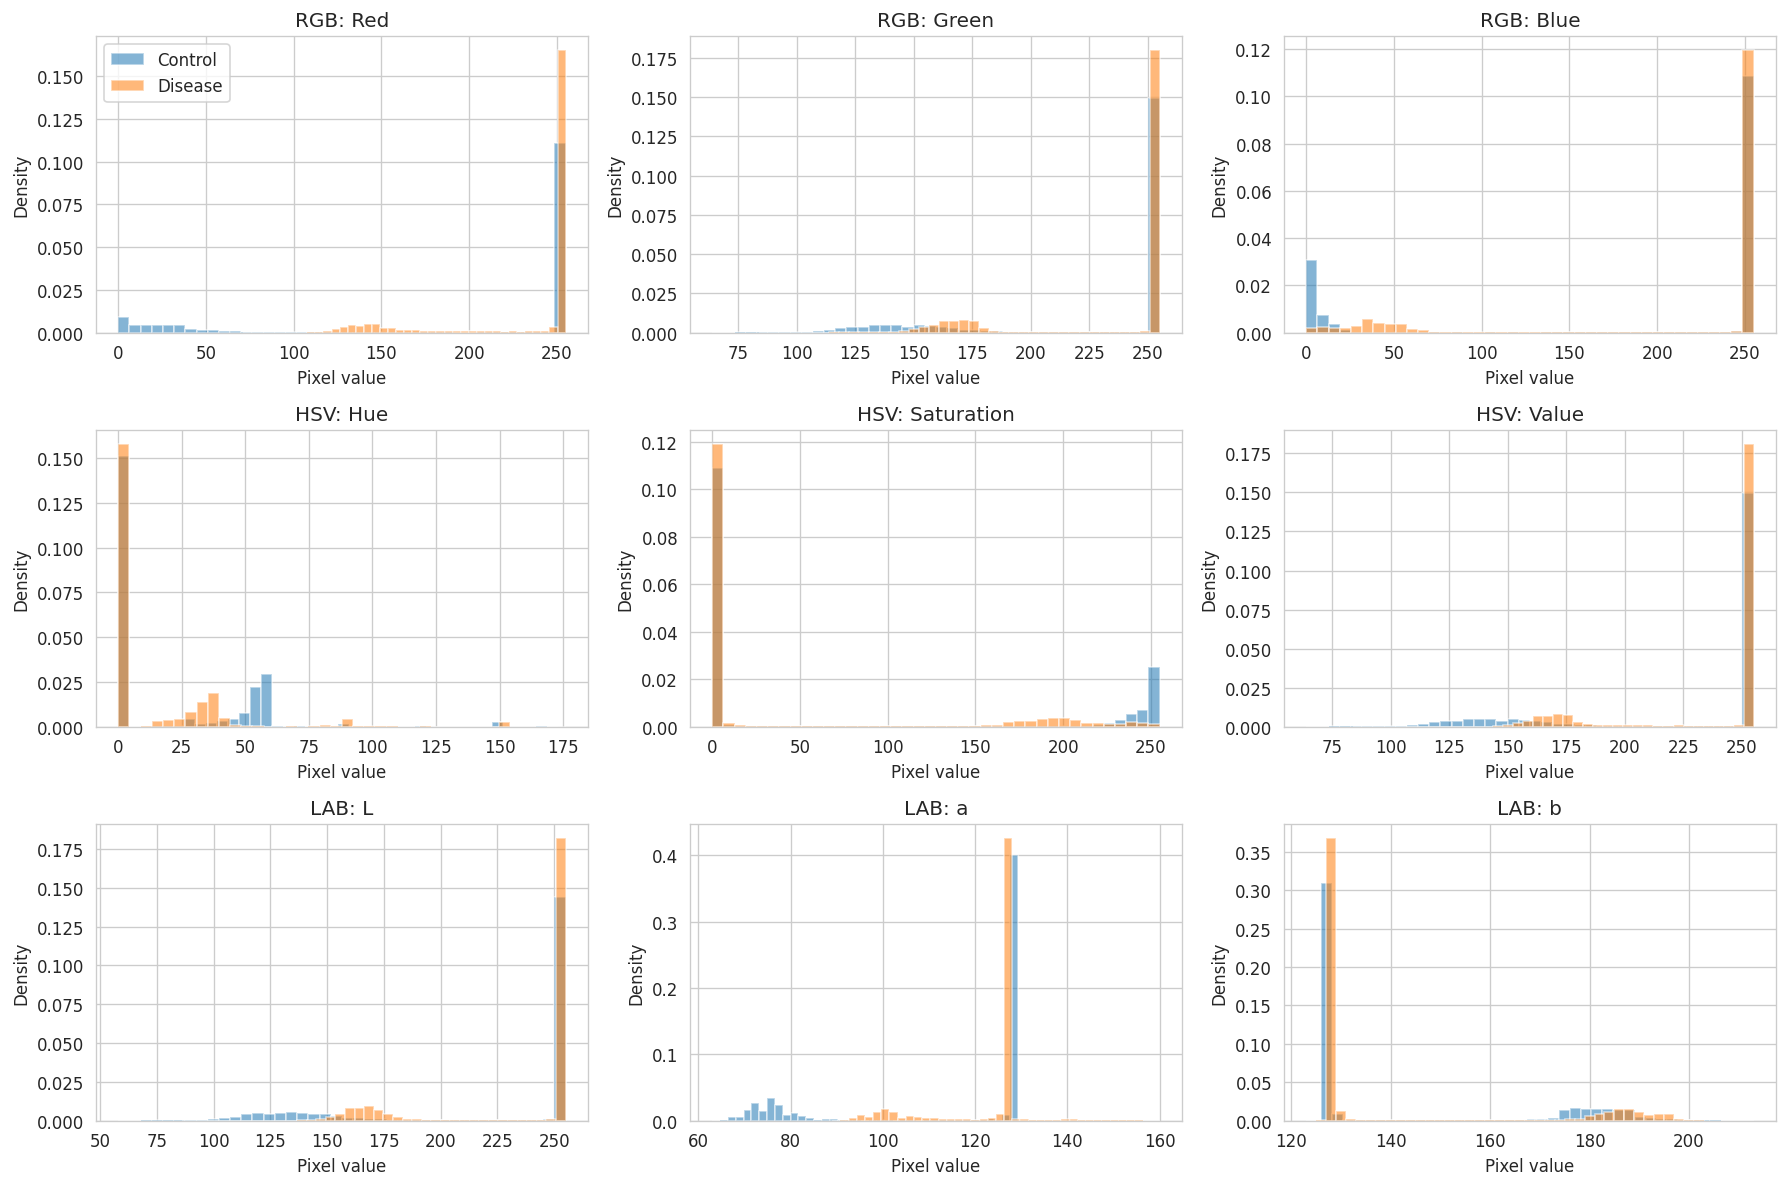

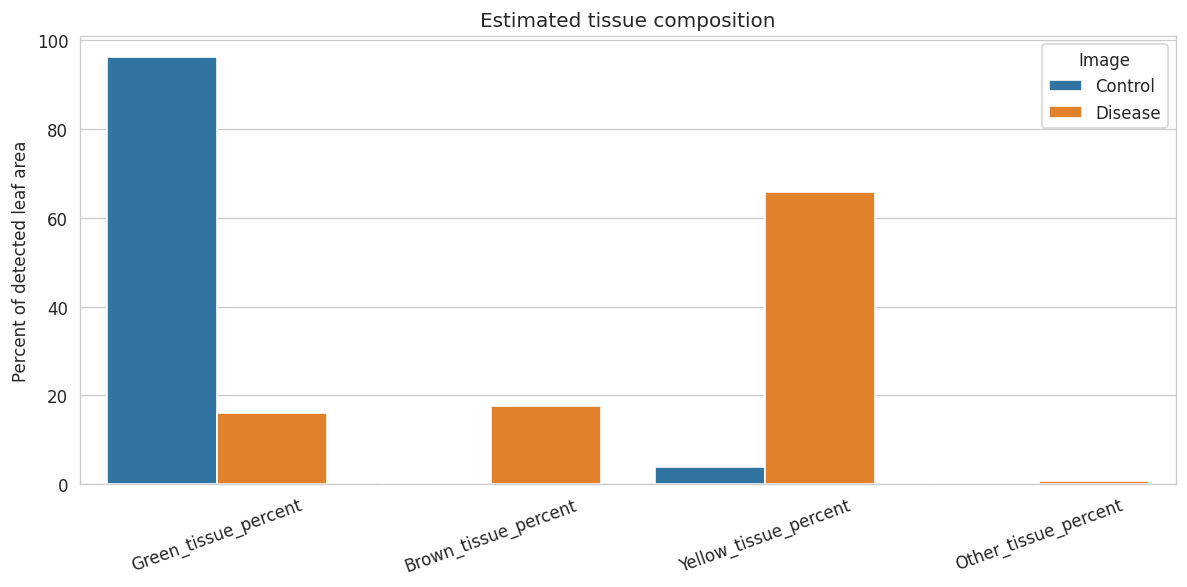

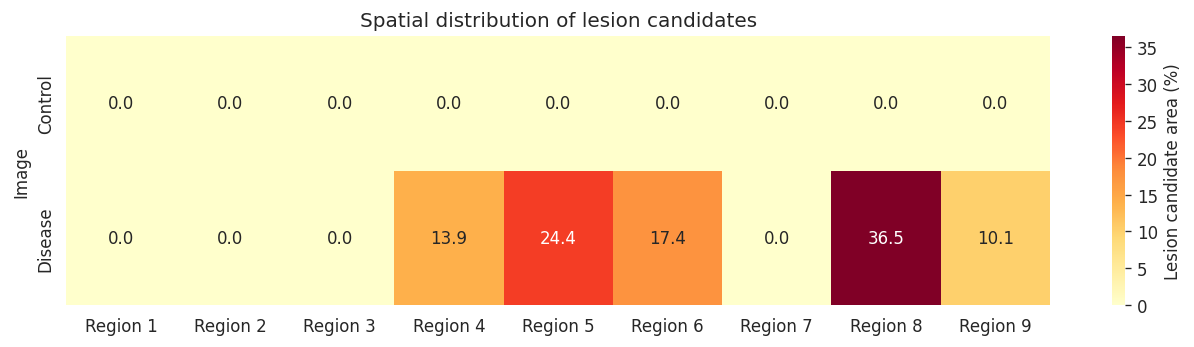

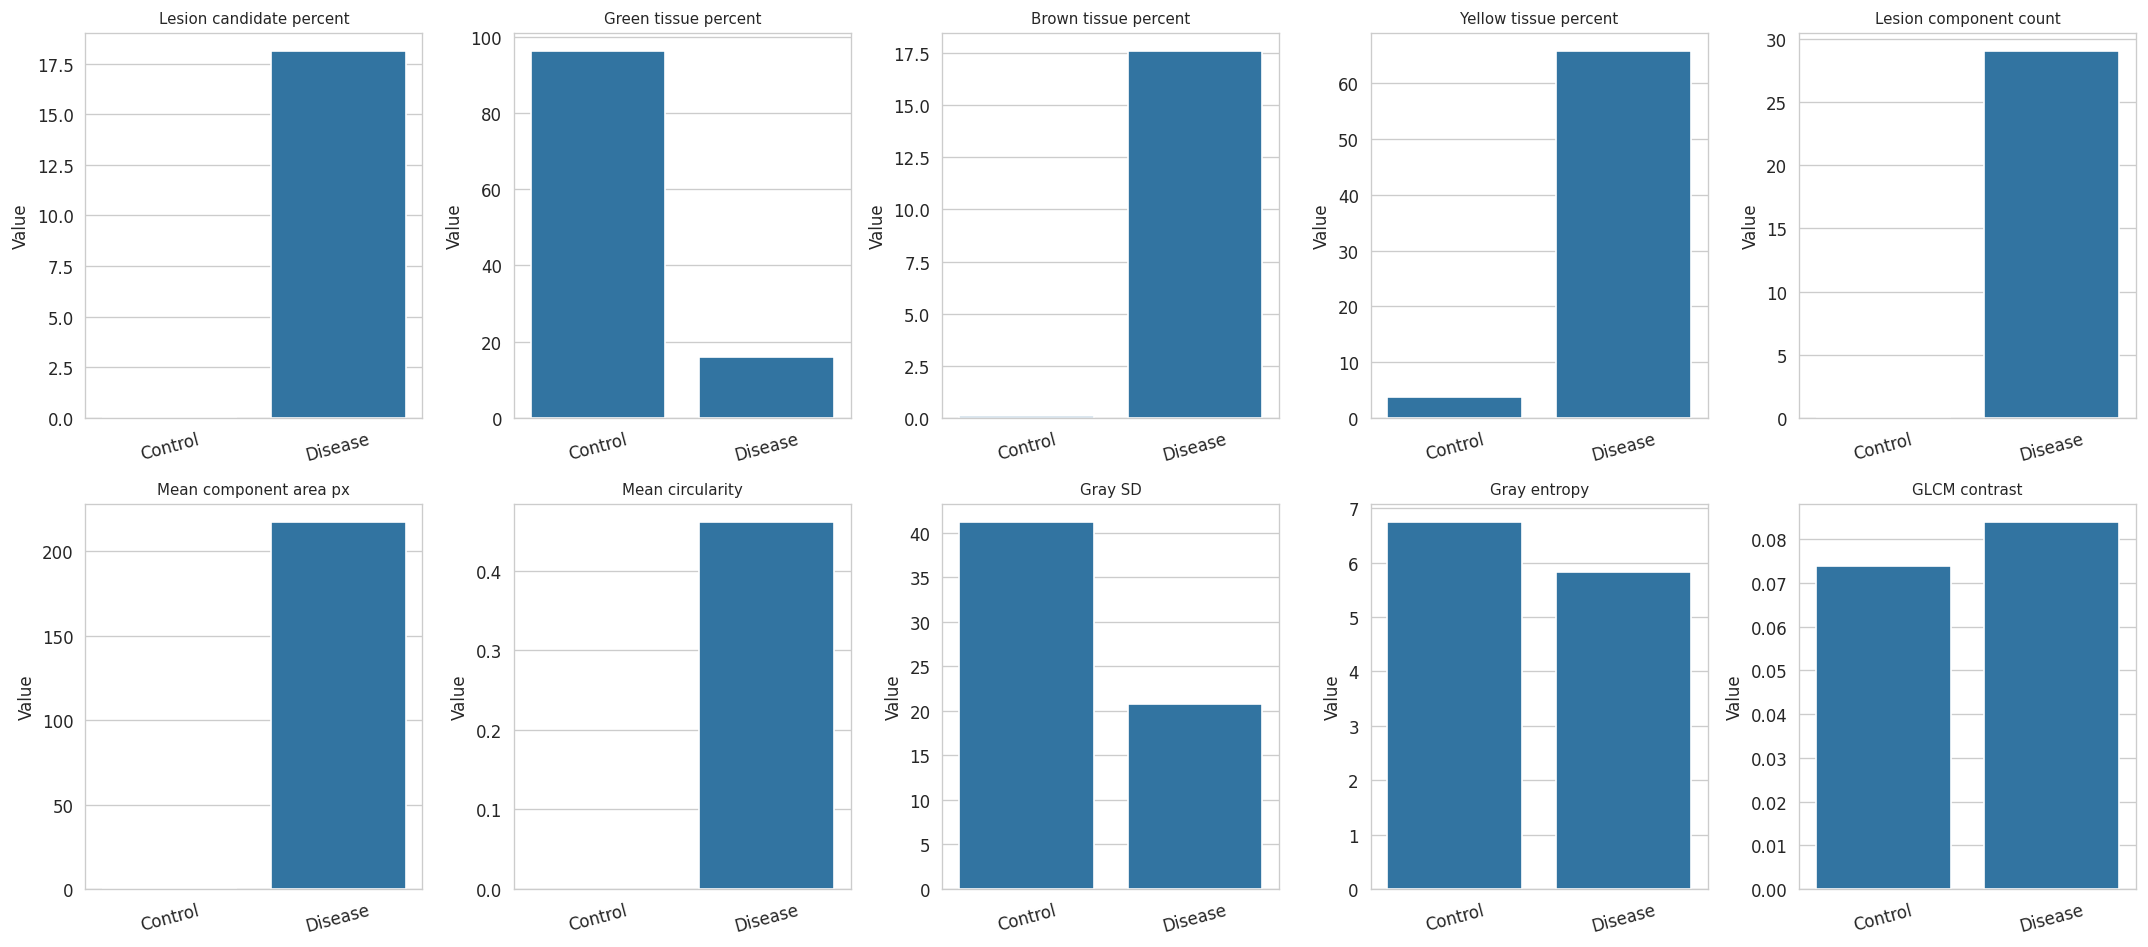


DETAILED IMAGE-DERIVED RESULTS


,0,1
Image,Control,Disease
Image_width,609,658
Image_height,256,234
Leaf_area_px,46687,34785
Lesion_candidate_area_px,0,6297
Lesion_candidate_percent,0.0,18.10263
Green_tissue_percent,96.187376,16.009774
Brown_tissue_percent,0.098528,17.579416
Yellow_tissue_percent,3.714096,65.755354
Other_tissue_percent,0.0,0.655455



DISEASE MINUS CONTROL


,Feature,Control,Disease,Disease_minus_Control
0,Image_width,609.000000,658.000000,49.000000
1,Image_height,256.000000,234.000000,-22.000000
2,Leaf_area_px,46687.000000,34785.000000,-11902.000000
3,Lesion_candidate_area_px,0.000000,6297.000000,6297.000000
4,Lesion_candidate_percent,0.000000,18.102630,18.102630
5,Green_tissue_percent,96.187376,16.009774,-80.177601
6,Brown_tissue_percent,0.098528,17.579416,17.480888
7,Yellow_tissue_percent,3.714096,65.755354,62.041258
8,Other_tissue_percent,0.000000,0.655455,0.655455
9,Lesion_component_count,0.000000,29.000000,29.000000



EXPLORATORY COMPARATIVE INTERPRETATION
Control leaf area: 46,687 pixels
Disease leaf area: 34,785 pixels

Estimated tissue composition:
Green_tissue_percent: Control=96.19% | Disease=16.01%
Brown_tissue_percent: Control=0.10% | Disease=17.58%
Yellow_tissue_percent: Control=3.71% | Disease=65.76%
Other_tissue_percent: Control=0.00% | Disease=0.66%

Lesion candidate estimates:
Control: 0.00% (0 connected regions)
Disease: 18.10% (29 connected regions)

Interpretation:
The disease image has a larger fraction of pixels classified as lesion candidates by this exploratory method.

CAUTION: Brown/yellow/dark regions may also reflect lighting, senescence, tissue damage, or other non-disease effects.
The color-distance result is not a disease probability and does not prove resistance or susceptibility.
One image per group cannot support biological statistical inference or deep-learning model validation.

Finished. Downloading all outputs...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
!pip -q install opencv-python-headless scikit-image pandas matplotlib seaborn

import os, cv2, zipfile, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from skimage.measure import shannon_entropy
from skimage.feature import graycomatrix, graycoprops
from IPython.display import display

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120
sns.set_style("whitegrid")

# ------------------------------------------------
# 1. UPLOAD IMAGES
# ------------------------------------------------
print("Upload two images: control first or disease first.")
uploaded = files.upload()

image_files = [
    f for f in uploaded.keys()
    if f.lower().endswith(
        (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")
    )
]

if len(image_files) < 2:
    raise ValueError("Please upload at least two image files.")

print("\nUploaded files:")
for i, f in enumerate(image_files):
    print(i, ":", f)

control_idx = int(input("\nEnter CONTROL image number: "))
disease_idx = int(input("Enter DISEASE image number: "))

if control_idx == disease_idx:
    raise ValueError("Select two different images.")

control_name = image_files[control_idx]
disease_name = image_files[disease_idx]

def load_rgb(path, max_dim=1400):
    image = cv2.imread(path)
    if image is None:
        raise ValueError("Could not read: " + path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    h, w = image.shape[:2]
    scale = min(1.0, max_dim / max(h, w))
    if scale < 1:
        image = cv2.resize(
            image,
            (int(w * scale), int(h * scale)),
            interpolation=cv2.INTER_AREA
        )
    return image

control_rgb = load_rgb(control_name)
disease_rgb = load_rgb(disease_name)

# ------------------------------------------------
# 2. LEAF SEGMENTATION
# ------------------------------------------------
# This estimates the leaf from green/yellow/brown/dark
# plant-like colors. Inspect the mask: it can fail with
# complex backgrounds or similarly colored objects.
# ------------------------------------------------
def leaf_segmentation(rgb):
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
    H, S, V = cv2.split(hsv)

    green = (H >= 20) & (H <= 105) & (S >= 25)
    yellow = (H >= 12) & (H <= 42) & (S >= 35) & (V >= 35)
    brown = (H >= 3) & (H <= 30) & (S >= 30) & (V < 210)
    dark_plant = (V < 90) & (S > 20)

    candidate = green | yellow | brown | dark_plant
    mask = candidate.astype(np.uint8) * 255

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)

    n, labels, stats, _ = cv2.connectedComponentsWithStats(mask, 8)

    if n > 1:
        largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        mask = (labels == largest).astype(np.uint8) * 255

    # Fallback if first pass captures very little of the image
    if np.mean(mask > 0) < 0.03:
        fallback = ((S > 15) & (V < 250)).astype(np.uint8) * 255
        n, labels, stats, _ = cv2.connectedComponentsWithStats(fallback, 8)
        if n > 1:
            largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
            fallback = (labels == largest).astype(np.uint8) * 255
        mask = fallback

    return mask

control_leaf = leaf_segmentation(control_rgb)
disease_leaf = leaf_segmentation(disease_rgb)

# ------------------------------------------------
# 3. TISSUE COLOR CLASSIFICATION
# ------------------------------------------------
# Uses HSV and LAB rules to distinguish:
#   green: healthy-looking green tissue
#   brown: brown/necrotic-looking tissue
#   yellow: yellow/chlorotic-looking tissue
#   other: remaining leaf pixels
#
# These are color categories, not confirmed pathology.
# ------------------------------------------------
def classify_tissue(rgb, leaf_mask):
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)

    H, S, V = cv2.split(hsv)
    L, A, B = cv2.split(lab)

    leaf = leaf_mask > 0

    green = leaf & (H >= 20) & (H <= 100) & (S >= 25)
    yellow = leaf & (H >= 15) & (H <= 38) & (S >= 35) & (V >= 65)
    brown = leaf & (
        ((H >= 3) & (H <= 28) & (S >= 30) & (V < 220))
        | ((V < 75) & (S > 20))
    )

    # Give brown priority, then yellow, then green
    brown = brown
    yellow = yellow & (~brown)
    green = green & (~brown) & (~yellow)

    other = leaf & (~brown) & (~yellow) & (~green)

    # Encoded categories:
    # 0 = background, 1 = green, 2 = brown, 3 = yellow, 4 = other
    category = np.zeros(leaf_mask.shape, dtype=np.uint8)
    category[green] = 1
    category[brown] = 2
    category[yellow] = 3
    category[other] = 4

    return category

control_tissue = classify_tissue(control_rgb, control_leaf)
disease_tissue = classify_tissue(disease_rgb, disease_leaf)

# ------------------------------------------------
# 4. CONTROL-REFERENCED COLOR DISTANCE
# ------------------------------------------------
# Estimates how different disease-image pixels are
# from the control image's green-tissue color profile.
#
# This is exploratory. Lighting, camera and genotype
# color differences can affect the result.
# ------------------------------------------------
def control_reference_distance(control_rgb, control_tissue,
                                disease_rgb, disease_leaf):
    control_lab = cv2.cvtColor(control_rgb, cv2.COLOR_RGB2LAB)
    disease_lab = cv2.cvtColor(disease_rgb, cv2.COLOR_RGB2LAB)

    reference_pixels = control_lab[control_tissue == 1]

    if len(reference_pixels) < 20:
        reference_pixels = control_lab[control_tissue > 0]

    if len(reference_pixels) < 20:
        raise ValueError(
            "Not enough control leaf pixels were detected. "
            "Check the control leaf mask."
        )

    # Robust reference center and spread
    ref_median = np.median(reference_pixels, axis=0)
    ref_mad = np.median(
        np.abs(reference_pixels - ref_median), axis=0
    )
    ref_scale = np.maximum(1.4826 * ref_mad, 5.0)

    # Standardized LAB distance
    distance = np.sqrt(
        np.sum(
            ((disease_lab.astype(float) - ref_median) / ref_scale) ** 2,
            axis=2
        )
    )

    distance[ disease_leaf == 0 ] = 0
    return distance, ref_median, ref_scale

color_distance, control_lab_median, control_lab_scale = (
    control_reference_distance(
        control_rgb, control_tissue,
        disease_rgb, disease_leaf
    )
)

# ------------------------------------------------
# 5. REFINED LESION-LIKE CANDIDATE MASK
# ------------------------------------------------
# Combines brown tissue color, dark tissue, and deviation
# from control green reference.
#
# A color-distance cutoff is used as a candidate flag,
# not as a disease probability.
# ------------------------------------------------
def refined_lesion_mask(rgb, leaf_mask, tissue, distance):
    leaf = leaf_mask > 0

    # Brown/necrotic-like category
    brown = tissue == 2

    # Dark regions inside leaf
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
    H, S, V = cv2.split(hsv)
    dark = leaf & (V < 75) & (S > 20)

    # Strong difference from control green reference
    different = leaf & (distance > 3.5)

    # Candidate mask:
    # Brown is strongest; dark and color deviation are
    # supplementary candidates.
    candidate = leaf & (brown | (dark & different) | (different & (tissue == 4)))

    mask = candidate.astype(np.uint8) * 255

    # Remove isolated noise while preserving larger regions
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)

    n, labels, stats, _ = cv2.connectedComponentsWithStats(mask, 8)
    cleaned = np.zeros_like(mask)

    min_area = max(8, int(mask.size * 0.000015))
    for i in range(1, n):
        area = stats[i, cv2.CC_STAT_AREA]
        if area >= min_area:
            cleaned[labels == i] = 255

    return cleaned

control_distance = np.zeros(control_leaf.shape, dtype=float)
control_lesion = refined_lesion_mask(
    control_rgb, control_leaf, control_tissue, control_distance
)
disease_lesion = refined_lesion_mask(
    disease_rgb, disease_leaf, disease_tissue, color_distance
)

# ------------------------------------------------
# 6. VISUALIZATION HELPERS
# ------------------------------------------------
def color_tissue_map(category):
    # RGB colors for tissue categories
    palette = np.array([
        [0, 0, 0],        # background
        [30, 170, 50],    # green
        [170, 75, 25],    # brown
        [245, 210, 30],   # yellow
        [140, 140, 140]   # other/uncertain
    ], dtype=np.uint8)
    return palette[category]

def make_overlay(rgb, mask):
    overlay = rgb.copy()
    selected = mask > 0
    overlay[selected] = (
        0.50 * overlay[selected] +
        0.50 * np.array([255, 0, 0])
    ).astype(np.uint8)
    return overlay

def make_contour_image(rgb, mask):
    out = rgb.copy()
    contours, _ = cv2.findContours(
        mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    cv2.drawContours(out, contours, -1, (255, 0, 0), 2)
    return out

control_overlay = make_overlay(control_rgb, control_lesion)
disease_overlay = make_overlay(disease_rgb, disease_lesion)

control_contours = make_contour_image(control_rgb, control_lesion)
disease_contours = make_contour_image(disease_rgb, disease_lesion)

# ------------------------------------------------
# 7. QUANTITATIVE FEATURES
# ------------------------------------------------
def calculate_features(rgb, leaf_mask, tissue, lesion_mask, label):
    leaf = leaf_mask > 0
    lesion = lesion_mask > 0
    leaf_n = int(np.sum(leaf))
    lesion_n = int(np.sum(lesion))

    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)

    leaf_rgb = rgb[leaf]
    leaf_hsv = hsv[leaf]
    leaf_lab = lab[leaf]

    # Tissue percentages
    green_n = int(np.sum(tissue == 1))
    brown_n = int(np.sum(tissue == 2))
    yellow_n = int(np.sum(tissue == 3))
    other_n = int(np.sum(tissue == 4))

    # Connected components
    n, labels, stats, centroids = cv2.connectedComponentsWithStats(
        lesion_mask, 8
    )
    areas = [
        int(stats[i, cv2.CC_STAT_AREA])
        for i in range(1, n)
        if stats[i, cv2.CC_STAT_AREA] > 0
    ]

    # Contour shape features
    contours, _ = cv2.findContours(
        lesion_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    circularity = []
    aspect_ratios = []

    for contour in contours:
        area = cv2.contourArea(contour)
        perimeter = cv2.arcLength(contour, True)

        if area > 0 and perimeter > 0:
            circularity.append(4 * np.pi * area / (perimeter ** 2))

        x, y, w, h = cv2.boundingRect(contour)
        if min(w, h) > 0:
            aspect_ratios.append(max(w, h) / min(w, h))

    # Texture
    gray_leaf = gray[leaf]
    gray_sd = float(np.std(gray_leaf)) if len(gray_leaf) else np.nan
    entropy = float(shannon_entropy(gray_leaf)) if len(gray_leaf) else np.nan

    lap = cv2.Laplacian(gray, cv2.CV_64F)
    lap_var = float(np.var(lap[leaf])) if np.any(leaf) else np.nan

    # GLCM computed on resized whole image; interpret cautiously
    small = cv2.resize(gray, (128, 128), interpolation=cv2.INTER_AREA)
    quant = (small // 16).astype(np.uint8)
    glcm = graycomatrix(
        quant, distances=[1], angles=[0],
        levels=16, symmetric=True, normed=True
    )

    # Spatial lesion distribution over 3x3 grid
    h, w = leaf_mask.shape
    grid = []
    for r in range(3):
        for c in range(3):
            y1, y2 = int(r*h/3), int((r+1)*h/3)
            x1, x2 = int(c*w/3), int((c+1)*w/3)
            local_leaf = leaf[y1:y2, x1:x2]
            local_lesion = lesion[y1:y2, x1:x2]
            grid.append(
                100 * np.sum(local_lesion) / max(np.sum(local_leaf), 1)
            )

    features = {
        "Image": label,
        "Image_width": w,
        "Image_height": h,
        "Leaf_area_px": leaf_n,
        "Lesion_candidate_area_px": lesion_n,
        "Lesion_candidate_percent": 100 * lesion_n / max(leaf_n, 1),
        "Green_tissue_percent": 100 * green_n / max(leaf_n, 1),
        "Brown_tissue_percent": 100 * brown_n / max(leaf_n, 1),
        "Yellow_tissue_percent": 100 * yellow_n / max(leaf_n, 1),
        "Other_tissue_percent": 100 * other_n / max(leaf_n, 1),
        "Lesion_component_count": len(areas),
        "Mean_component_area_px": np.mean(areas) if areas else 0,
        "Largest_component_area_px": max(areas) if areas else 0,
        "Mean_circularity": np.mean(circularity) if circularity else np.nan,
        "Mean_aspect_ratio": np.mean(aspect_ratios) if aspect_ratios else np.nan,
        "RGB_R_mean": np.mean(leaf_rgb[:, 0]) if len(leaf_rgb) else np.nan,
        "RGB_G_mean": np.mean(leaf_rgb[:, 1]) if len(leaf_rgb) else np.nan,
        "RGB_B_mean": np.mean(leaf_rgb[:, 2]) if len(leaf_rgb) else np.nan,
        "HSV_H_mean": np.mean(leaf_hsv[:, 0]) if len(leaf_hsv) else np.nan,
        "HSV_S_mean": np.mean(leaf_hsv[:, 1]) if len(leaf_hsv) else np.nan,
        "HSV_V_mean": np.mean(leaf_hsv[:, 2]) if len(leaf_hsv) else np.nan,
        "LAB_L_mean": np.mean(leaf_lab[:, 0]) if len(leaf_lab) else np.nan,
        "LAB_a_mean": np.mean(leaf_lab[:, 1]) if len(leaf_lab) else np.nan,
        "LAB_b_mean": np.mean(leaf_lab[:, 2]) if len(leaf_lab) else np.nan,
        "Gray_SD": gray_sd,
        "Gray_entropy": entropy,
        "Laplacian_variance": lap_var,
        "GLCM_contrast": graycoprops(glcm, "contrast")[0, 0],
        "GLCM_homogeneity": graycoprops(glcm, "homogeneity")[0, 0],
        "GLCM_energy": graycoprops(glcm, "energy")[0, 0],
        "GLCM_correlation": graycoprops(glcm, "correlation")[0, 0],
    }

    for i, value in enumerate(grid, 1):
        features[f"Grid_{i}_lesion_percent"] = value

    return features

control_features = calculate_features(
    control_rgb, control_leaf, control_tissue, control_lesion, "Control"
)
disease_features = calculate_features(
    disease_rgb, disease_leaf, disease_tissue, disease_lesion, "Disease"
)

results = pd.DataFrame([control_features, disease_features])

# ------------------------------------------------
# 8. IMAGE QUALITY CONTROL PANEL
# ------------------------------------------------
fig, axes = plt.subplots(2, 5, figsize=(19, 8))

panel_data = [
    ("Original", control_rgb, disease_rgb, False),
    ("Leaf mask", control_leaf, disease_leaf, True),
    ("Tissue categories", color_tissue_map(control_tissue),
     color_tissue_map(disease_tissue), False),
    ("Lesion candidates", control_lesion, disease_lesion, True),
    ("Lesion overlay", control_overlay, disease_overlay, False)
]

for col, (title, c_img, d_img, gray) in enumerate(panel_data):
    for row, (name, img) in enumerate([
        ("CONTROL", c_img), ("DISEASE", d_img)
    ]):
        ax = axes[row, col]
        ax.imshow(img, cmap="gray" if gray else None)
        ax.set_title(f"{name}\n{title}")
        ax.axis("off")

plt.tight_layout()
plt.savefig("01_quality_control_masks.png", bbox_inches="tight")
plt.show()

# ------------------------------------------------
# 9. COLOR DISTANCE MAP
# ------------------------------------------------
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(disease_rgb)
plt.title("Disease image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(color_distance, cmap="magma")
plt.colorbar(label="Standardized LAB distance")
plt.title("Difference from control green reference")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(disease_overlay)
plt.title("Detected lesion candidates")
plt.axis("off")

plt.tight_layout()
plt.savefig("02_control_reference_distance.png", bbox_inches="tight")
plt.show()

# ------------------------------------------------
# 10. COLOR DISTRIBUTIONS — CORRECTED 3x3 GRID
# ------------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(15, 10))

color_spaces = [
    ("RGB", control_rgb, disease_rgb, ["Red", "Green", "Blue"]),
    ("HSV",
     cv2.cvtColor(control_rgb, cv2.COLOR_RGB2HSV),
     cv2.cvtColor(disease_rgb, cv2.COLOR_RGB2HSV),
     ["Hue", "Saturation", "Value"]),
    ("LAB",
     cv2.cvtColor(control_rgb, cv2.COLOR_RGB2LAB),
     cv2.cvtColor(disease_rgb, cv2.COLOR_RGB2LAB),
     ["L", "a", "b"])
]

for row, (space, ci, di, channels) in enumerate(color_spaces):
    for ch in range(3):
        ax = axes[row, ch]
        ax.hist(ci[:, :, ch].ravel(), bins=40, alpha=0.55,
                density=True, label="Control")
        ax.hist(di[:, :, ch].ravel(), bins=40, alpha=0.55,
                density=True, label="Disease")
        ax.set_title(f"{space}: {channels[ch]}")
        ax.set_xlabel("Pixel value")
        ax.set_ylabel("Density")
        if row == 0 and ch == 0:
            ax.legend()

plt.tight_layout()
plt.savefig("03_color_distributions.png", bbox_inches="tight")
plt.show()

# ------------------------------------------------
# 11. TISSUE COMPOSITION COMPARISON
# ------------------------------------------------
tissue_cols = [
    "Green_tissue_percent",
    "Brown_tissue_percent",
    "Yellow_tissue_percent",
    "Other_tissue_percent"
]

tissue_plot = results[["Image"] + tissue_cols].melt(
    id_vars="Image", var_name="Tissue", value_name="Percent"
)

plt.figure(figsize=(10, 5))
sns.barplot(data=tissue_plot, x="Tissue", y="Percent", hue="Image")
plt.ylabel("Percent of detected leaf area")
plt.xlabel("")
plt.title("Estimated tissue composition")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("04_tissue_composition.png", bbox_inches="tight")
plt.show()

# ------------------------------------------------
# 12. SPATIAL LESION DISTRIBUTION
# ------------------------------------------------
grid_cols = [f"Grid_{i}_lesion_percent" for i in range(1, 10)]
grid_df = results.set_index("Image")[grid_cols]
grid_df.columns = [f"Region {i}" for i in range(1, 10)]

plt.figure(figsize=(11, 3))
sns.heatmap(
    grid_df, annot=True, fmt=".1f",
    cmap="YlOrRd",
    cbar_kws={"label": "Lesion candidate area (%)"}
)
plt.title("Spatial distribution of lesion candidates")
plt.tight_layout()
plt.savefig("05_spatial_distribution.png", bbox_inches="tight")
plt.show()

# ------------------------------------------------
# 13. FEATURE COMPARISON
# ------------------------------------------------
key_features = [
    "Lesion_candidate_percent",
    "Green_tissue_percent",
    "Brown_tissue_percent",
    "Yellow_tissue_percent",
    "Lesion_component_count",
    "Mean_component_area_px",
    "Mean_circularity",
    "Gray_SD",
    "Gray_entropy",
    "GLCM_contrast"
]

plot_df = results[["Image"] + key_features].melt(
    id_vars="Image", var_name="Feature", value_name="Value"
)

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, feature in enumerate(key_features):
    sns.barplot(
        data=plot_df[plot_df["Feature"] == feature],
        x="Image", y="Value", ax=axes[i]
    )
    axes[i].set_title(feature.replace("_", " "), fontsize=9)
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig("06_feature_comparison.png", bbox_inches="tight")
plt.show()

# ------------------------------------------------
# 14. FEATURE DIFFERENCE TABLE
# ------------------------------------------------
numeric_cols = results.select_dtypes(include=np.number).columns

difference_rows = []
for feature in numeric_cols:
    c = results.loc[0, feature]
    d = results.loc[1, feature]
    difference_rows.append({
        "Feature": feature,
        "Control": c,
        "Disease": d,
        "Disease_minus_Control": d - c
    })

differences = pd.DataFrame(difference_rows)

print("\nDETAILED IMAGE-DERIVED RESULTS")
display(results.T)

print("\nDISEASE MINUS CONTROL")
display(differences)

results.to_csv("refined_image_features.csv", index=False)
differences.to_csv("refined_control_disease_differences.csv", index=False)

# ------------------------------------------------
# 15. AUTOMATIC INTERPRETATION
# ------------------------------------------------
c = control_features
d = disease_features

print("\n" + "="*72)
print("EXPLORATORY COMPARATIVE INTERPRETATION")
print("="*72)

print(f"Control leaf area: {c['Leaf_area_px']:,} pixels")
print(f"Disease leaf area: {d['Leaf_area_px']:,} pixels")

print("\nEstimated tissue composition:")
for key in tissue_cols:
    print(
        f"{key}: Control={c[key]:.2f}% | Disease={d[key]:.2f}%"
    )

print("\nLesion candidate estimates:")
print(
    f"Control: {c['Lesion_candidate_percent']:.2f}% "
    f"({c['Lesion_component_count']} connected regions)"
)
print(
    f"Disease: {d['Lesion_candidate_percent']:.2f}% "
    f"({d['Lesion_component_count']} connected regions)"
)

print("\nInterpretation:")
if d["Lesion_candidate_percent"] > c["Lesion_candidate_percent"]:
    print(
        "The disease image has a larger fraction of pixels classified "
        "as lesion candidates by this exploratory method."
    )
else:
    print(
        "The disease image does not have a larger lesion-candidate "
        "fraction under the current thresholds."
    )

print(
    "\nCAUTION: Brown/yellow/dark regions may also reflect lighting, "
    "senescence, tissue damage, or other non-disease effects."
)
print(
    "The color-distance result is not a disease probability and "
    "does not prove resistance or susceptibility."
)
print(
    "One image per group cannot support biological statistical "
    "inference or deep-learning model validation."
)

# ------------------------------------------------
# 16. SAVE OUTPUT IMAGES
# ------------------------------------------------
def save_rgb(path, img):
    cv2.imwrite(path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

save_rgb("control_tissue_categories.png", color_tissue_map(control_tissue))
save_rgb("disease_tissue_categories.png", color_tissue_map(disease_tissue))
save_rgb("control_lesion_overlay.png", control_overlay)
save_rgb("disease_lesion_overlay.png", disease_overlay)
save_rgb("control_contours.png", control_contours)
save_rgb("disease_contours.png", disease_contours)

cv2.imwrite("control_leaf_mask.png", control_leaf)
cv2.imwrite("disease_leaf_mask.png", disease_leaf)
cv2.imwrite("control_lesion_candidates.png", control_lesion)
cv2.imwrite("disease_lesion_candidates.png", disease_lesion)

# Save color-distance map
distance_norm = color_distance.copy()
distance_norm = np.clip(distance_norm / 10.0, 0, 1)
distance_img = (distance_norm * 255).astype(np.uint8)
cv2.imwrite("disease_control_color_distance.png", distance_img)

# ------------------------------------------------
# 17. WRITE REPORT NOTES
# ------------------------------------------------
with open("analysis_interpretation.txt", "w") as f:
    f.write("CONTROL vs DISEASE LEAF IMAGE ANALYSIS\n")
    f.write("Exploratory computer-vision analysis; not trained deep learning.\n\n")
    f.write(f"Control file: {control_name}\n")
    f.write(f"Disease file: {disease_name}\n\n")
    f.write(f"Control leaf area: {c['Leaf_area_px']}\n")
    f.write(f"Disease leaf area: {d['Leaf_area_px']}\n")
    f.write(
        f"Control lesion candidate percent: "
        f"{c['Lesion_candidate_percent']:.4f}\n"
    )
    f.write(
        f"Disease lesion candidate percent: "
        f"{d['Lesion_candidate_percent']:.4f}\n"
    )
    f.write(
        f"Control brown tissue percent: {c['Brown_tissue_percent']:.4f}\n"
    )
    f.write(
        f"Disease brown tissue percent: {d['Brown_tissue_percent']:.4f}\n"
    )
    f.write(
        f"Control yellow tissue percent: {c['Yellow_tissue_percent']:.4f}\n"
    )
    f.write(
        f"Disease yellow tissue percent: {d['Yellow_tissue_percent']:.4f}\n\n"
    )
    f.write(
        "Interpretation limitation: pixel classes are color-based estimates. "
        "They are not confirmed disease lesions or validated severity scores.\n"
    )
    f.write(
        "One image per group is insufficient for statistical inference, "
        "biological resistance conclusions, or deep-learning validation.\n"
    )

# ------------------------------------------------
# 18. ZIP AND DOWNLOAD
# ------------------------------------------------
output_files = [
    "01_quality_control_masks.png",
    "02_control_reference_distance.png",
    "03_color_distributions.png",
    "04_tissue_composition.png",
    "05_spatial_distribution.png",
    "06_feature_comparison.png",
    "refined_image_features.csv",
    "refined_control_disease_differences.csv",
    "analysis_interpretation.txt",
    "control_tissue_categories.png",
    "disease_tissue_categories.png",
    "control_lesion_overlay.png",
    "disease_lesion_overlay.png",
    "control_contours.png",
    "disease_contours.png",
    "control_leaf_mask.png",
    "disease_leaf_mask.png",
    "control_lesion_candidates.png",
    "disease_lesion_candidates.png",
    "disease_control_color_distance.png"
]

with zipfile.ZipFile("refined_leaf_comparison_results.zip", "w") as z:
    for filename in output_files:
        if os.path.exists(filename):
            z.write(filename)

print("\nFinished. Downloading all outputs...")
files.download("refined_leaf_comparison_results.zip")